# Demand-Side Management MPC (DSMPC) HALL AND ERDIN

Copyright &copy; 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

## Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import casadi
import cvxpy as cp
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import LightSource
import matplotlib.transforms as mtransforms
from matplotlib.patches import Polygon, Patch
from matplotlib.collections import PatchCollection
from matplotlib import colormaps
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC, CEMPC
from IPython.display import clear_output
from utils import adjust_margins

In [3]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

In [4]:
# Define LaTeX preamble for beamer
preamble = r"""
    \usepackage{amsmath,amsthm,amssymb,amsfonts}
    \usepackage{color}

    % === Font ====================================================================
    \usepackage[T1]{fontenc}       % for correct hyphenation and T1 encoding
    \usepackage{lmodern}           % latin modern font
    \linespread{1.12}              % enlarge line space
    \renewcommand{\familydefault}{\sfdefault}

    % === Math Packages ===========================================================
    \usepackage{amsthm,bm}         % for bold math symbols

    % === Icons ===================================================================
    \usepackage{fontawesome5}      % for icons
"""

## Approximate Infinite-Horizon Overtaking-Optimal Trajectory

In [5]:
# Define period length and number of periods
T, N = 96, 6

# Load parameters and create system with a long horizon
zeta_max = 10 * np.ones([T,10]); zeta_max[23::24,:] = 1; zeta_max[42] = 15
params_inf = DSMPCParams(N=N*T, T=T, zeta_max=zeta_max, zeta_min=-zeta_max)
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = EMPC(sys_inf, params_inf.ctrl, solver='cvxpy')

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_inf, _ = ctrl_inf.solve(t=0)
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_inf = sol_x.T
u_inf = sol_u.T

## Simulate System Without Terminal Ingredients

### Solve DSMPC for Varying Initial States

In [6]:
# Load parameters and create system
params = DSMPCParams(T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
sys = LinearSystem(params.sys)

# Initialize controller
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([9.9/4*i, 14.9/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
x = np.full((num_traj, num_steps+1, sys.n), np.nan)
u = np.full((num_traj, num_steps,   sys.m), np.nan)
x_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
u_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories', leave=False)):
    # Set initial state
    x[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=x[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            x_ol[i,:] = sol_x.T
            u_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Solve DSMPC for Varying Horizons

In [7]:
# Setup simulation
horizon = [6, 9, 12, 18, 24, 36, 48]
num_horizon = len(horizon)

# Allocate state and input trajectories
x2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
u2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
x2_ol = np.full((num_horizon, num_steps, max(horizon)+1, sys.n), np.nan)
u2_ol = np.full((num_horizon, num_steps, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons', leave=False)):
    # Load parameters and create system
    params2 = DSMPCParams(N=N, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = EMPC(sys2, params2.ctrl)

    # Set initial state
    x2[i,0,:] = np.tile(np.array([7.5, 11.25]), 10)

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=x2[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        x2_ol[i,t,:N+1,:] = sol_x.T
        u2_ol[i,t,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        u2[i,t,:]   = sol_u[:,0]
        x2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Feasible Region

In [84]:
# Allocate feasible set
horizon_f = [48, 36, 24, 12, 6, 1]
num_horizon_f = len(horizon_f)

# Define angles to sample
num = 6
angles = np.arctan2(np.hstack([np.linspace(0, 15, num=num), np.tile(15, num), np.linspace(15, 0, num=num)]),
                    np.hstack([np.tile(10, num), np.linspace(10, -10, num=num), np.tile(-10, num)]))
angles = np.unique(angles)

# Compute radii for all angles
with np.errstate(divide='ignore', invalid='ignore'):
    rx = np.where(np.cos(angles) != 0, np.maximum(-10 / np.cos(angles), 10 / np.cos(angles)), np.inf)
    ry = np.where(np.sin(angles) != 0, np.maximum(  0 / np.sin(angles), 15 / np.sin(angles)), np.inf)

# Take element-wise minimum
r0 = np.minimum(rx, ry)

# Sample feasible set
feasible_set = [[],[],[]]
for N in tqdm(horizon_f, desc=' Horizons', leave=False):
    # Initialize controller
    params.ctrl.N = N
    ctrl3 = EMPC(sys, params.ctrl)
    
    # Sample state space (in polar coordinates)
    xf_0 = [[],[]]
    for i, phi in enumerate(tqdm(angles,desc='   Angles', leave=False)):
        # Perform line-search along r
        xf_0[0].append(np.nan)
        xf_0[1].append(np.nan)
        for r in tqdm(np.linspace(r0[i], 0, num=10),desc='Linesearch', leave=False):
            # Compute initial state
            x0_r = np.tile([r*np.cos(phi), r*np.sin(phi)], params.M)

            # Allocate closed-loop trajectory
            ur = np.full((num_steps, sys.m), np.nan)
            xr = np.full((num_steps+1, sys.n), np.nan)
            xr[0,:] = x0_r

            # Simulate closed-loop system
            success = True
            for t in tqdm(range(num_steps),desc='     MPC', leave=False):
                # Solve the EMPC problem
                sol_u, sol_x, error_msg, _, _ = ctrl3.solve(t=t, x_0=xr[t,:])
                if error_msg != None:
                    success = False
                    break

                # Save closed-loop trajectory
                ur[t,:]   = sol_u[:,0]
                xr[t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

            # Check if problem was feasible
            if not success:
                continue

            # Check if closed-loop trajectory converged to the infinite horizon solution
            diff = np.linalg.norm(xr - x_inf[2*T:2*T+num_steps+1,:], axis=1)
            if np.all(diff[-6:] < 6):
                # Save feasible region
                xf_0[0][-1] = x0_r[0]
                xf_0[1][-1] = x0_r[1]

                # Update r_max
                r0[i] = r
                break
            sleep(0.01)
    
    # Check if problem was feasible
    if np.isnan(xf_0[0][-1]):
        warnings.warn(f'Feasibility problem for N = {N} and phi = {phi:.2f} was infeasible.')
    
    # Stack vectors
    xf_0[0] = np.stack([xf_0[0]])
    xf_0[1] = np.stack([xf_0[1]])

    # Save feasible set
    feasible_set[0].append(xf_0[0])
    feasible_set[1].append(xf_0[1])
    feasible_set[2].append(np.tile(N, (1, xf_0[0].shape[1])))

# Stack vectors
feasible_set[0] = np.vstack(feasible_set[0])
feasible_set[1] = np.vstack(feasible_set[1])
feasible_set[2] = np.vstack(feasible_set[2])
feasible_set = np.stack(feasible_set)

# Clear cell output
clear_output()

### Open- and Closed-Loop Trajectories

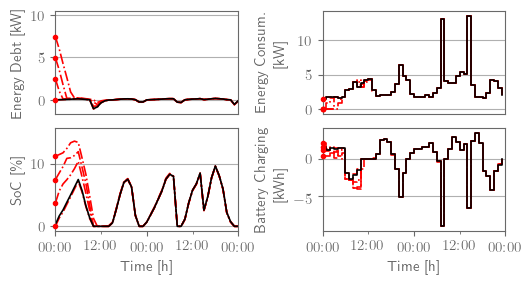

In [8]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 11
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['text.latex.preamble'] = preamble

# Create time vector
agent = 9
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
label = r'$(x^v,u^v)$'
for i in range(num_traj):
    axs[0][0].plot(dates, x[i,:,agent*2], color='red', linestyle='-.', label=label if i == 0 else None)
    axs[1][0].plot(dates, x[i,:,agent*2+1], color='red', linestyle='-.', label=label if i == 0 else None)
    axs[0][1].plot(dates[:-1], u[i,:,agent*2], color='red', linestyle='-.', drawstyle='steps-post', label=label if i == 0 else None)
    axs[1][1].plot(dates[:-1], u[i,:,agent*2+1], color='red', linestyle='-.', drawstyle='steps-post', label=label if i == 0 else None)
    if not np.all(np.isnan(x[i,1:,agent*2])):
        axs[0][0].plot(dates[0], x[i,0,agent*2], color='red', marker='o', markersize=3, zorder=10, clip_on=False)
        axs[1][0].plot(dates[0], x[i,0,agent*2+1], color='red', marker='o', markersize=3, zorder=10, clip_on=False)
        axs[0][1].plot(dates[0], u[i,0,agent*2], color='red', marker='o', markersize=3, zorder=10, clip_on=False)
        axs[1][1].plot(dates[0], u[i,0,agent*2+1], color='red', marker='o', markersize=3, zorder=10, clip_on=False)

# Plot approximate overtaking-optimal trajectories
label = r'$(x^\star,u^\star)$'
for i in [2]:
    axs[0][0].plot(dates, x_inf[i*T:i*T+num_steps+1,agent*2], color='black', linestyle='-', label=label)
    axs[1][0].plot(dates, x_inf[i*T:i*T+num_steps+1,agent*2+1], color='black', linestyle='-', label=label)
    axs[0][1].plot(dates[:-1], u_inf[i*T:i*T+num_steps,agent*2], color='black', linestyle='-', drawstyle='steps-post', label=label)
    axs[1][1].plot(dates[:-1], u_inf[i*T:i*T+num_steps,agent*2+1], color='black', linestyle='-', drawstyle='steps-post', label=label)

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\textnormal{Energy Debt [kW]}')
axs[1][0].set_ylabel(r'\textnormal{SoC [\%]}')
axs[0][1].set_ylabel(r'\textnormal{Energy Consum.}\par\quad\qquad\textnormal{[kW]}')
axs[1][1].set_ylabel(r'\textnormal{Battery Charging}\par\quad\quad\textnormal{[kWh]}')
axs[1][0].set_xlabel(r'\textnormal{Time [h]}')
axs[1][1].set_xlabel(r'\textnormal{Time [h]}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12])) # [6, 12, 18]
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Plot legend
# fig.legend(*axs[0][1].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5, 0.11), ncol=2)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4.5, height=2.2, wspace=1.3, hspace=0.4, top=0.1) #, bottom=1)
    fig.savefig(f"figures/figure_closed_loop_agent_{agent+1}_beamer.pdf")

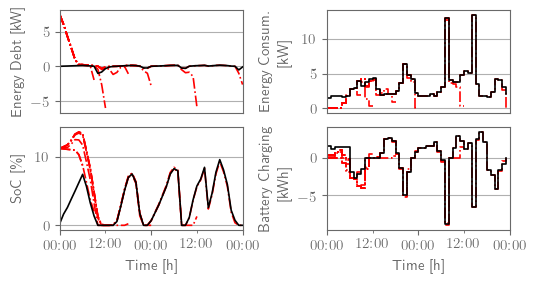

In [9]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 11
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['text.latex.preamble'] = preamble

# Create time vector
t = 0
agent = 9
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(max(horizon)+1)]

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories
label = r'$\bigl(x_{\smash{\bullet|t}}^v,u_{\smash{\bullet|t}}^v\bigr)$'
for i, _ in enumerate(horizon):
    axs[0][0].plot(dates_ol, x2_ol[i,t,:,agent*2], color='red', linestyle='-.', label=label if i == 0 else None)
    axs[1][0].plot(dates_ol, x2_ol[i,t,:,agent*2+1], color='red', linestyle='-.', label=label if i == 0 else None)
    axs[0][1].plot(dates_ol[:-1], u2_ol[i,t,:,agent*2], color='red', linestyle='-.', drawstyle='steps-post', label=label if i == 0 else None)
    axs[1][1].plot(dates_ol[:-1], u2_ol[i,t,:,agent*2+1], color='red', linestyle='-.', drawstyle='steps-post', label=label if i == 0 else None)

# Plot approximate overtaking-optimal trajectories
label = r'$\bigl(x^\star,u^\star\bigr)$'
for i in [2]:
    axs[0][0].plot(dates, x_inf[t+i*T:t+i*T+num_steps+1,agent*2], color='black', linestyle='-', label=label)
    axs[1][0].plot(dates, x_inf[t+i*T:t+i*T+num_steps+1,agent*2+1], color='black', linestyle='-', label=label)
    axs[0][1].plot(dates[:-1], u_inf[t+i*T:t+i*T+num_steps,agent*2], color='black', linestyle='-', drawstyle='steps-post', label=label)
    axs[1][1].plot(dates[:-1], u_inf[t+i*T:t+i*T+num_steps,agent*2+1], color='black', linestyle='-', drawstyle='steps-post', label=label)

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\textnormal{Energy Debt [kW]}')
axs[1][0].set_ylabel(r'\textnormal{SoC [\%]}')
axs[0][1].set_ylabel(r'\textnormal{Energy Consum.}\par\quad\qquad\textnormal{[kW]}')
axs[1][1].set_ylabel(r'\textnormal{Battery Charging}\par\quad\quad\textnormal{[kWh]}')
axs[1][0].set_xlabel(r'\textnormal{Time [h]}')
axs[1][1].set_xlabel(r'\textnormal{Time [h]}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates_ol[0], dates_ol[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Plot legend
# fig.legend(*axs[0][1].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5, 0.112), ncol=2)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4.5, height=2.2, wspace=1.3, hspace=0.4, top=0.1) #, bottom=1)
    fig.savefig(f"figures/figure_open_loop_agent{agent+1}_beamer.pdf")

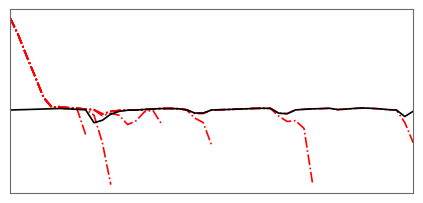

In [17]:
# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories
label = r'$\bigl(x_{\smash{\bullet|t}}^v,u_{\smash{\bullet|t}}^v\bigr)$'
for i, _ in enumerate(horizon):
    ax.plot(dates_ol, x2_ol[i,t,:,agent*2], color='red', linestyle='-.', label=label if i == 0 else None)

# Plot approximate overtaking-optimal trajectories
label = r'$\bigl(x^\star,u^\star\bigr)$'
for i in [2]:
    ax.plot(dates, x_inf[t+i*T:t+i*T+num_steps+1,agent*2], color='black', linestyle='-', label=label)

# Add labels
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Set axis limits
ax.set_xlim([dates_ol[0], dates_ol[-1]])

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5, width=4.032, height=1.837) #, bottom=1)
    fig.savefig(f"figures/figure_open_loop_turnpike_beamer.pdf")

### Turnpike Plots

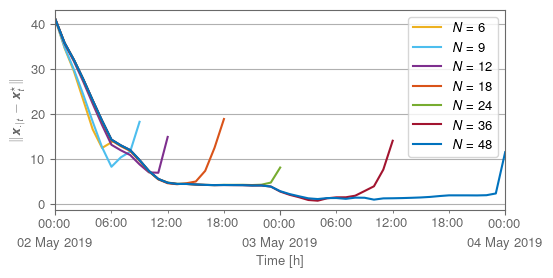

In [ ]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = preamble

# Create time vector
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+max(horizon)+1)]

# Compute L2-norm
diff_x2_ol = np.full((num_horizon, num_steps, num_steps+max(horizon)+1), np.nan)
for i in range(num_horizon):
    for t in range(num_steps):
        diff_x2_ol[i,t,t:t+horizon[i]+1] = np.linalg.norm(x2_ol[i,t,:horizon[i]+1,:] - x_inf[t+2*T:t+2*T+horizon[i]+1,:], axis=1)  

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
t = 0
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_horizon):
    axs.plot(dates, diff_x2_ol[i,t,:], color=colors(num_horizon-i-1), linestyle='-', label=f'$N = {horizon[i]}$')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_{\bullet|t} - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\textnormal{Time [h]}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[max(horizon)]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
axs.legend(loc='best')

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4.5, height=2, wspace=1.1)
    fig.savefig(f"figures/figure_turnpike_L2norm_t0_{t:0.1f}_beamer.pdf")

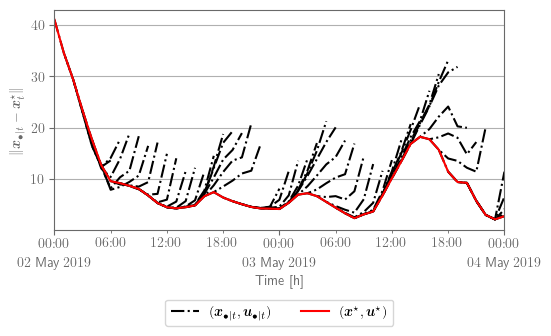

In [33]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = preamble

# Create time vector
idx = 0
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+max(horizon)+1)]

# Compute L2-norm
diff_x = np.full((num_horizon, num_steps+1), np.nan)
diff_x_ol = np.full((num_horizon, num_steps, num_steps+max(horizon)+1), np.nan)
for i in range(num_horizon):
    diff_x[i,:] = np.linalg.norm(x2[i,:,:] - x_inf[2*T:2*T+num_steps+1,:], axis=1)
    for t in range(num_steps):
        diff_x_ol[i,t,t:t+horizon[i]+1] = np.linalg.norm(x2_ol[i,t,:horizon[i]+1,:] - x_inf[t+2*T:t+2*T+horizon[i]+1,:], axis=1)    

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(12, 4), layout='constrained')

# Plot open-loop trajectories
for t in range(num_steps):
    axs.plot(dates, diff_x_ol[idx,t,:], color='black', linestyle='-.', label=r'$(\bm{x}_{\bullet|t},\bm{u}_{\bullet|t})$' if t == 0 else None)

# Plot closed-loop trajectory
axs.plot(dates[:num_steps+1], diff_x[idx,:], color='red', linestyle='-', label = r'$(\bm{x}^\star,\bm{u}^\star)$')

# Add labels
axs.set_ylabel(r"$\|\bm{x}_{\bullet|t} - \bm{x}_t^\star\|$")
axs.set_xlabel(r'\textnormal{Time [h]}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set axis limits
axs.set_xlim([dates[0], dates[max(horizon)]])
# axs.set_xlim([dates[0], dates[num_steps+horizon[idx]-1]])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)
# axs.set_yscale('log')

# Align labels
fig.align_labels()

# Plot legend
handles, labels = axs.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.112), ncol=2)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4.5, height=2.2, wspace=1.3, hspace=0.4, top=0.1, bottom=1)
    fig.savefig(f"figures/figure_turnpike_L2norm.pdf")

## Simulate System With Terminal Ingredients

### Compute Periodic Reference Trajectory

In [9]:
# Define period length
T = 96

# Load parameters and create periodic system
params_p = DSMPCParams(N=T, T=T, zeta_max=zeta_max, zeta_min=-zeta_max, verbose=False)
sys_p = LinearSystem(params_p.sys)

# Initialize controller
ctrl_p = CEMPC(sys_p, params_p.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_p, stats = ctrl_p.solve(options={'eps_rel': 1E-10, 'eps_abs': 1E-10})
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_p = sol_x.T
u_p = sol_u.T
dual_vector_p = np.hstack(dual_vars_p[0:ctrl_p.params.N]).T

Convexification problem solved with minimal eigenvalue: 0.09995340898761196
LMIs is positive definite for all times.


### Solve DSMPC for Varying Initial States

In [10]:
# Initialize controller
paramst = ctrl_p.params
paramst.N = 24
ctrl = EMPC(sys_p, paramst)

# Setup simulation
xt_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(xt_0)

# Allocate state and input trajectories
xt = np.full((num_traj, num_steps+1, sys.n), np.nan)
ut = np.full((num_traj, num_steps,   sys.m), np.nan)
xt_ol = np.full((num_traj, paramst.N+1, sys.n), np.nan)
ut_ol = np.full((num_traj, paramst.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(xt_0, desc='Trajectories', leave=False)):
    # Set initial state
    xt[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=xt[i,t,:], x_T=x_p[t+paramst.N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt_ol[i,:] = sol_x.T
            ut_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        ut[i,t,:]   = sol_u[:,0]
        xt[i,t+1,:] = sys_p.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Solve DSMPC for Varying Horizons

In [11]:
# Setup simulation
horizont = [24, 36, 48]
num_horizont = len(horizont)

# Allocate state and input trajectories
xt2 = np.full((num_horizont, num_steps+1, sys.n), np.nan)
ut2 = np.full((num_horizont, num_steps,   sys.m), np.nan)
xt2_ol = np.full((num_horizont, num_steps, max(horizont)+1, sys.n), np.nan)
ut2_ol = np.full((num_horizont, num_steps, max(horizont),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizont, desc='Horizons', leave=False)):
    # Load parameters and create system
    paramst.N = N

    # Initialize controller
    ctrl2 = EMPC(sys_p, paramst)

    # Set initial state
    xt2[i,0,:] = np.tile(np.array([10, 15]), 10)

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=xt2[i,t,:], x_T=x_p[t+N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        xt2_ol[i,t,:N+1,:] = sol_x.T
        ut2_ol[i,t,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        ut2[i,t,:]   = sol_u[:,0]
        xt2[i,t+1,:] = sys_p.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output()

### Compare Cost

In [ ]:
# Compute cost with and without terminal constraints
data = []
for i in range(num_traj):
    cost, costt = 0, 0
    for k in range(num_steps):
        cost  += params.ctrl.stage_cost(x[i, k],  u[i, k],  t=k)[0]
        costt += paramst.ctrl.stage_cost(xt[i, k], ut[i, k], t=k)[0]
    
    # Append the computed costs
    data.append([cost, costt, np.abs(cost/costt-1)*100])

# Create a pandas DataFrame
columns = pd.MultiIndex.from_tuples([('Cost', 'Without'), ('Cost', 'With'), ('Rel. Diff','[%]')])
cost_df = pd.DataFrame(data, columns=columns, index=pd.Index(range(num_traj), name="Trajectory"))
cost_df

Cost               Rel. Diff
                 Without          With       [%]
Trajectory                                      
0           30299.257848  30492.171578  0.632666
1           27929.364426  28110.231222  0.643420
2           27517.128678  27731.613309  0.773430
3           30044.941144           NaN       NaN
4                    NaN           NaN       NaN

### Asymptotic Convergence

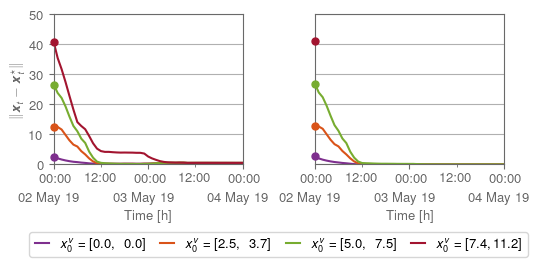

In [12]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = preamble

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute L2-norm
diff_x = np.full((num_traj, num_steps+1), np.nan)
diff_xt = np.full((num_traj, num_steps+1), np.nan)
for i in range(num_traj):
    diff_x[i,:] = np.linalg.norm(x[i,:,:] - x_inf[2*T:2*T+num_steps+1,:], axis=1)
    diff_xt[i,:] = np.linalg.norm(xt[i] - x_p[:num_steps+1], axis=1)

# Create colormap
colors = lambda i: ["#0072BD", "#A2142F", "#77AC30", "#D95319", "#7E2F8E", "#4DBEEE", "#EDB120"][i % 7]

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    if not np.all(np.isnan(diff_x[i,1:])):
        label_name = '[{:3.1f},{:4.1f}]'.format(*x_0[i]).replace(' ', r'\phantom{0}')
        axs[0].plot(dates, diff_x[i,:], color=colors(num_traj-i-1), linestyle='-', label=f'$x_0^v = {label_name}$')
        axs[0].plot(dates[0], diff_x[i,0], color=colors(num_traj-i-1), marker='o', markersize=5, zorder=10, clip_on=False)
        axs[1].plot(dates, diff_xt[i,:], color=colors(num_traj-i-1), linestyle='-', label=f'$x_0^v = {label_name}$')
        axs[1].plot(dates[0], diff_xt[i,0], color=colors(num_traj-i-1), marker='o', markersize=5, zorder=10, clip_on=False)

# Add labels
axs[0].set_xlabel(r'\textnormal{Time [h]}')
axs[1].set_xlabel(r'\textnormal{Time [h]}')
axs[0].set_ylabel(r"$\|\bm{x}_t - \bm{x}_t^\star\|$")
axs[1].tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
    
    # Shift major xtick labels horizontally
    for label in ax.get_xticklabels():
        offset = mtransforms.ScaledTranslation(-0.05, 0, fig.dpi_scale_trans)
        label.set_transform(label.get_transform() + offset)

for ax in axs:
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])
    ax.set_ylim([0, 10*np.ceil((diff_x[3,0])/10)])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Plot legend
fig.legend(*axs[1].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5, 0.15), ncol=4, columnspacing=1, handlelength=1.0)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4.5, height=1.5, wspace=1, bottom=1)
    fig.savefig(f"figures/figure_asymptotic_convergence_L2norm_beamer.pdf")

### Feasible Region

In [13]:
# Allocate feasible set
horizon_f = range(1,49)
num_horizon_f = len(horizon_f)

# Sample feasible set
t = 0
feasible_set2 = [[],[],[]]
for i, N in enumerate(tqdm(horizon_f, desc='Horizons', leave=False)):
    # Define decision variables
    r = cp.Variable(nonneg=True)
    x_r = cp.Variable((sys.n, N + 1))
    u_r = cp.Variable((sys.m, N))
    x0_r = cp.Parameter((sys.n))

    # Define dynamics constraints
    dynamics_constraints = []
    for k in range(N):
        dynamics_constraints += [x_r[:,k+1].reshape((sys_p.n,1)) == sys_p.f(x_r[:,k], u_r[:,k], t=t+k)]

    # Define state and input constraints
    input_constraints = []
    state_constraints = [x_r[:,0] == r*x0_r]
    for k in range(N):
        input_constraints += [paramst.h_u(u_r[:,k], t=t+k) <= 0]
        state_constraints += [paramst.h_x(x_r[:,k], t=t+k) <= 0]
    state_constraints += [x_r[:,N] == x_p[t+N,:]]

    # Setup solver
    prob = cp.Problem(cp.Maximize(r), dynamics_constraints + state_constraints + input_constraints)

    # Sample state space (in polar coordinates)
    xf_0 = [[],[]]
    angles = 2*np.pi * np.arange(31) / 30
    for phi in tqdm(angles,desc='    OCP', leave=False):
        # Set initial parameter
        x0_r.value = np.tile([np.cos(phi), np.sin(phi)], params_p.M)

        # Solve feasibility problem
        prob.solve()
        if prob.status == cp.OPTIMAL:
            r_val = r.value
            xf_0[0].append(r_val*np.cos(phi))
            xf_0[1].append(r_val*np.sin(phi))
        else:
            xf_0[0].append(None)
            xf_0[1].append(None)
            warnings.warn(f'Feasibility problem for N = {N} and phi = {phi:.2f} was infeasible.')
        sleep(0.01)
    
    # Stack vectors
    xf_0[0] = np.stack([xf_0[0]])
    xf_0[1] = np.stack([xf_0[1]])

    # Save feasible set (with 8 steps in N)
    feasible_set2[0].append(np.tile(xf_0[0], (8,1)))
    feasible_set2[1].append(np.tile(xf_0[1], (8,1)))
    feasible_set2[2].append(np.tile(np.linspace(N,N+1, num=8).reshape(-1,1), (1, xf_0[0].shape[1])))

# Stack vectors
feasible_set2[0] = np.vstack(feasible_set2[0])
feasible_set2[1] = np.vstack(feasible_set2[1])
feasible_set2[2] = np.vstack(feasible_set2[2])
feasible_set2 = np.stack(feasible_set2)

# Clear cell output
clear_output()

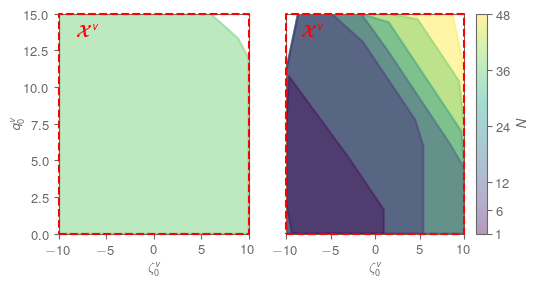

In [86]:
# Set rcParams
export = True
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = preamble

# Define function to update edge alpha
def update_edgealpha(fig, collection, alpha=1):
    fig.canvas.draw()
    edge_colors = collection.get_edgecolor()
    edge_colors[:, 3] = alpha
    collection.set_edgecolor(edge_colors)

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout='constrained', gridspec_kw={'width_ratios': [1.7, 2]})

# Plot 2d-projection
patches = [[], []]
colors = [[], []]
colors[0] = [48, 36]
for i, _ in enumerate(colors[0]):
    # Plot feasible set without terminal ingredients
    patches[0].append(Polygon(feasible_set[0:2,i-1].T))

colors[1] = [48, 36, 24, 12, 6, 1]
for i, N in enumerate(colors[1]):
    # Plot feasible set with terminal ingredients
    idx = max(*np.where(feasible_set2[2,:,0] == N))
    patches[1].append(Polygon(feasible_set2[0:2,idx].T))

# Add patches to subfigure
p = PatchCollection(patches[0], alpha=0.4, edgecolor='face', linewidth=1.5)
p1 = PatchCollection(patches[1], alpha=0.4, edgecolor='face', linewidth=1.5)
p.set_array(colors[1])
p1.set_array(colors[1])
axs[0].add_collection(p)
axs[1].add_collection(p1)
if not export:
    fig.colorbar(p1, ax=axs[1], ticks=colors[1], location='right', label=r"$N$")
    update_edgealpha(fig, p, 1)
    update_edgealpha(fig, p1, 1)

# Plot state constraint
for ax in axs:
    ax.plot([-10,10,10,-10,-10],[0,0,15,15,0], color='red', linestyle='--', linewidth=1.5, label=None, zorder=10, clip_on=False)
    ax.text(0.2, 0.95, r'$\boldsymbol{\mathcal{X}}^v$', fontsize=12, color='red', ha='right', va='top', transform=ax.transAxes)

    # Set axis limits
    ax.set_xlim(-10, 10)
    ax.set_ylim(0, 15)

# Add labels
axs[0].set_ylabel(r"$q_0^v$", labelpad=0)
axs[0].set_xlabel(r"$\zeta_0^v$")
axs[1].set_xlabel(r"$\zeta_0^v$")
axs[1].tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4.5, height=2.2, wspace=0.5)
    fig.colorbar(p, ax=axs[1], ticks=colors[1], location='right', label=r"$N$")
    fig.savefig(f"figures/figure_feasible_region_empc_beamer.pdf")

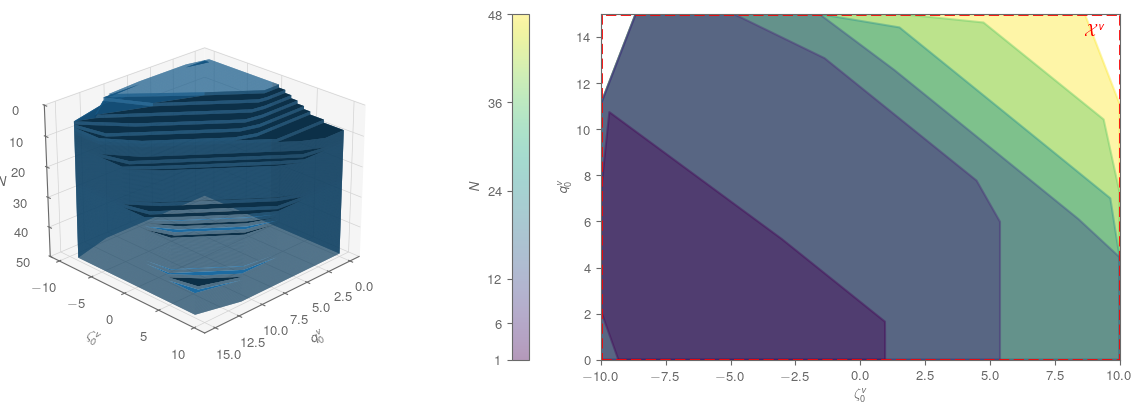

In [17]:
# Set rcParams
export = False
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = preamble

# Define function to update edge alpha
def update_edgealpha(fig, collection, alpha=1):
    fig.canvas.draw()
    edge_colors = collection.get_edgecolor()
    edge_colors[:, 3] = alpha
    collection.set_edgecolor(edge_colors)

# Create figure
axs = [[],[]]
fig = plt.figure(figsize=(12, 4), layout='constrained')
axs[0] = fig.add_subplot(1, 2, 1, projection='3d')
axs[1] = fig.add_subplot(1, 2, 2)

# Plot 3d-surface
axs[0].plot_surface(*feasible_set2, rstride=1, cstride=10, linewidth=0, antialiased=True, alpha=1, shade=True, lightsource=LightSource(azdeg=-180, altdeg=45))

# Plot 2d-projection
patches = []
colors = [48, 36, 24, 12, 6, 1]
for i, N in enumerate(colors):
    idx = max(*np.where(feasible_set2[2,:,0] == N))
    patches.append(Polygon(feasible_set2[0:2,idx].T))

# Add patches to subfigure
p = PatchCollection(patches, alpha=0.4, edgecolor='face', linewidth=1.5)
p.set_array(colors)
axs[1].add_collection(p)
if not export:
    fig.colorbar(p, ax=axs[1], ticks=colors, location='left', label=r"$N$")
    update_edgealpha(fig, p, 1)

# Plot state constraint
axs[1].plot([-10,10,10,-10,-10],[0,0,15,15,0], color='red', linestyle='--', linewidth=2, label=None)
axs[1].text(0.97, 0.97, r'$\mathcal{X}^v$', fontsize=12, color='red', ha='right', va='top', transform=axs[1].transAxes)

# Add labels
axs[0].set_zlabel(r"$N$")
axs[0].set_ylabel(r"$q_0^v$")
axs[0].set_xlabel(r"$\zeta_0^v$")
axs[1].set_ylabel(r"$q_0^v$")
axs[1].set_xlabel(r"$\zeta_0^v$")
axs[0].zaxis.labelpad=-2

# Set axis limits
axs[0].set_zlim(0, 50)
axs[1].set_xlim(feasible_set2[0,:].min(), feasible_set2[0,:].max().round())
axs[1].set_ylim(feasible_set2[1,:].min(), feasible_set2[1,:].max().round())

# Set grid
axs[0].xaxis._axinfo['grid'].update(color='lightgray', linestyle='-', linewidth=0.5)
axs[0].yaxis._axinfo['grid'].update(color='lightgray', linestyle='-', linewidth=0.5)
axs[0].zaxis._axinfo['grid'].update(color='lightgray', linestyle='-', linewidth=0.5)

# Set background color
axs[0].xaxis.set_pane_color('whitesmoke')
axs[0].yaxis.set_pane_color('whitesmoke')
axs[0].zaxis.set_pane_color('whitesmoke')

# Set ticks
axs[0].zaxis._axinfo['juggled'] = (1, 2, 0)
# ax.set(xticklabels=[], yticklabels=[],  zticklabels=[])

# Set view angle
axs[0].view_init(elev=-155, azim=225)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=5, height=2.5, wspace=1.0)
    fig.colorbar(p, ax=axs[1], ticks=colors, location='right', label=r"$N$")
    fig.savefig(f"figures/figure_feasible_region_cempc_t_{t:0.1f}_beamer.pdf")

### Figure Numerical Example

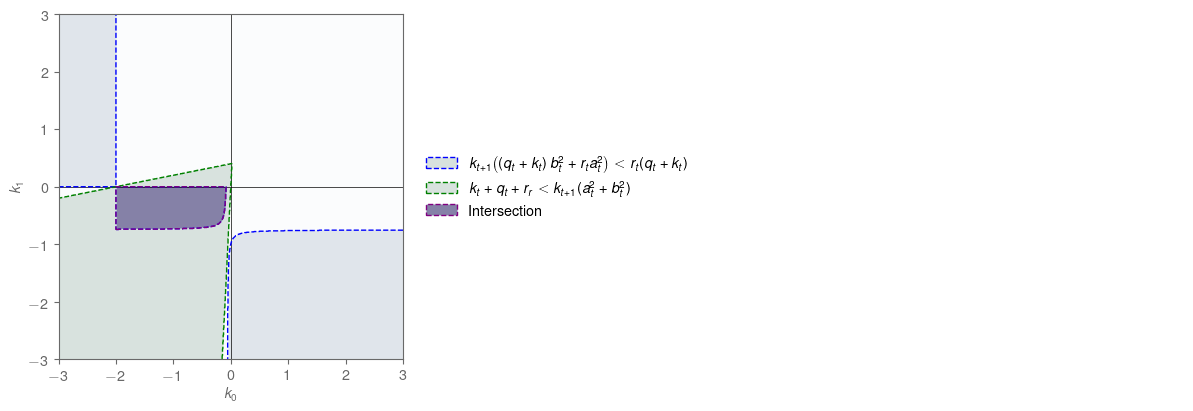

In [ ]:
# Set rcParams
export = False
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['text.latex.preamble'] = preamble

# Define meshgrid
d = np.linspace(-3,3,1000)
k0,k1 = np.meshgrid(d,d)

# Define variables
a0=1; a1=-2; b0=2; b1=4
q0=2; q1=1; r0=0; r1=-1

# Compute sets
set1 = ((k1*((k0 + q0) * b0**2 + r0 * a0**2) < r0*(q0 + k0)) & (k0*((k1 + q1) * b1**2 + r1 * a1**2) < r1*(q1 + k1))).astype(int)
set2 = ((k0 + q0 + r0 > k1*(a0**2 + b0**2)) & (k1 + q1 + r1 > k0*(a1**2 + b1**2))).astype(int)

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

# Plot first inequalities

axs[0].contour(k0, k1, set1, levels=[0.5], colors='blue', linewidths=1, linestyles='--')
axs[0].imshow(set1, extent=(k0.min(),k0.max(),k1.min(),k1.max()), origin="lower", cmap="Blues", alpha = 0.2)

# Plot second inequalities
axs[0].contour(k0, k1, set2, levels=[0.5], colors='green', linewidths=1, linestyles='--')
axs[0].imshow(set2, extent=(k0.min(),k0.max(),k1.min(),k1.max()),origin="lower", cmap="Greens", alpha = 0.2)

# Plot union of feasible sets
axs[0].contour(k0, k1, (set1 & set2).astype(int), levels=[0.5], colors='purple', linewidths=1, linestyles='--', )
axs[0].imshow((set1 & set2).astype(int), extent=(k0.min(),k0.max(),k1.min(),k1.max()),origin="lower", cmap="Purples", alpha = 0.3)

# Create patches (proxy artist) 
patches = [Patch(facecolor='#d8e2de', edgecolor='blue', linestyle='--', label=r"$k_{t+1}\bigl((q_t + k_t)\, b_t^2 + r_t a_t^2\bigr) < r_t(q_t + k_t)$"), 
           Patch(facecolor='#d8e2de', edgecolor='green', linestyle='--', label=r"$k_t + q_t + r_r < k_{t+1}(a_t^2 + b_t^2)$"), 
           Patch(facecolor='#8581a7', edgecolor='purple', linestyle='--', label=r"\textnormal{Intersection}")]

# Disable 2nd axis
axs[1].axis('off')

# Add axis lines
axs[0].axhline(0,color='black', linewidth=0.5, zorder=0)
axs[0].axvline(0,color='black', linewidth=0.5, zorder=0)

# Set x-ticks
axs[0].set_xticks(np.arange(-3,4,1))

# Set axis limits
axs[0].set_xlim(-3,3)
axs[0].set_ylim(-3,3)
axs[0].set_xlabel(r'$k_0$')
axs[0].set_ylabel(r'$k_1$')

# Plot legend
axs[0].legend(handles=patches, bbox_to_anchor=(1.05, 0.5), loc='center left' , borderaxespad=0, frameon=False)

# Export figure
if export:
    fig = adjust_margins(fig, textwidth=5.512, width=4, height=2, wspace=0, hspace=0)
    fig.savefig(f"figures/figure_rotation_of_indefinite_cost_beamer.pdf")